In [1]:
import pandas as pd
airline=pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')

In [2]:
airline.head(5)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
airline['Month']=pd.to_datetime(airline['Month'])

In [4]:
airline

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [5]:
airline.set_index('Month',inplace=True)

In [6]:
airline

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


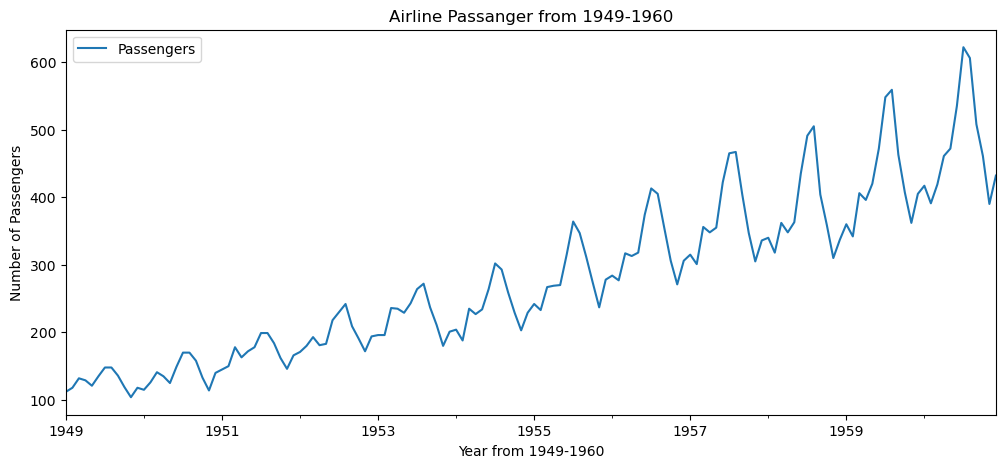

In [7]:
import matplotlib.pyplot as plt
airline.plot(figsize=(12,5))
plt.title("Airline Passanger from 1949-1960")
plt.ylabel("Number of Passengers")
plt.xlabel("Year from 1949-1960")
plt.show()

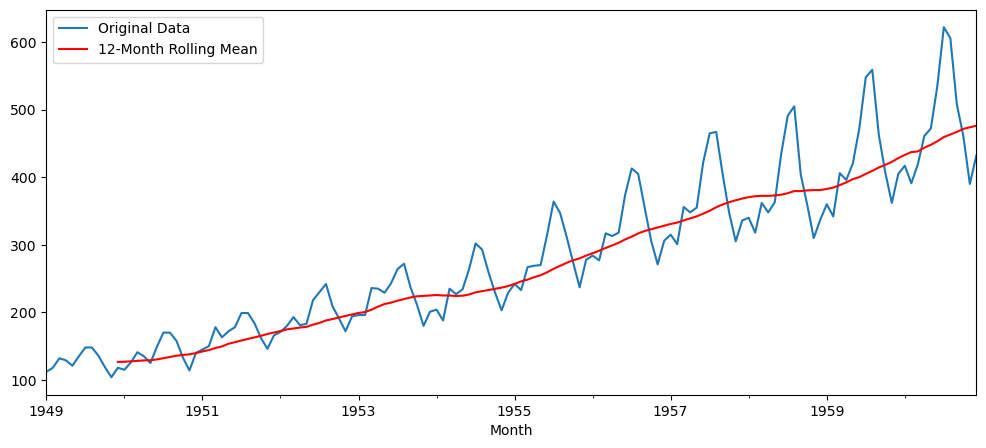

In [8]:
airline['Passengers'].plot(figsize=(12,5), label='Original Data')
airline['Passengers'].rolling(window=12).mean().plot(color='red', label='12-Month Rolling Mean')
plt.legend()
plt.show()

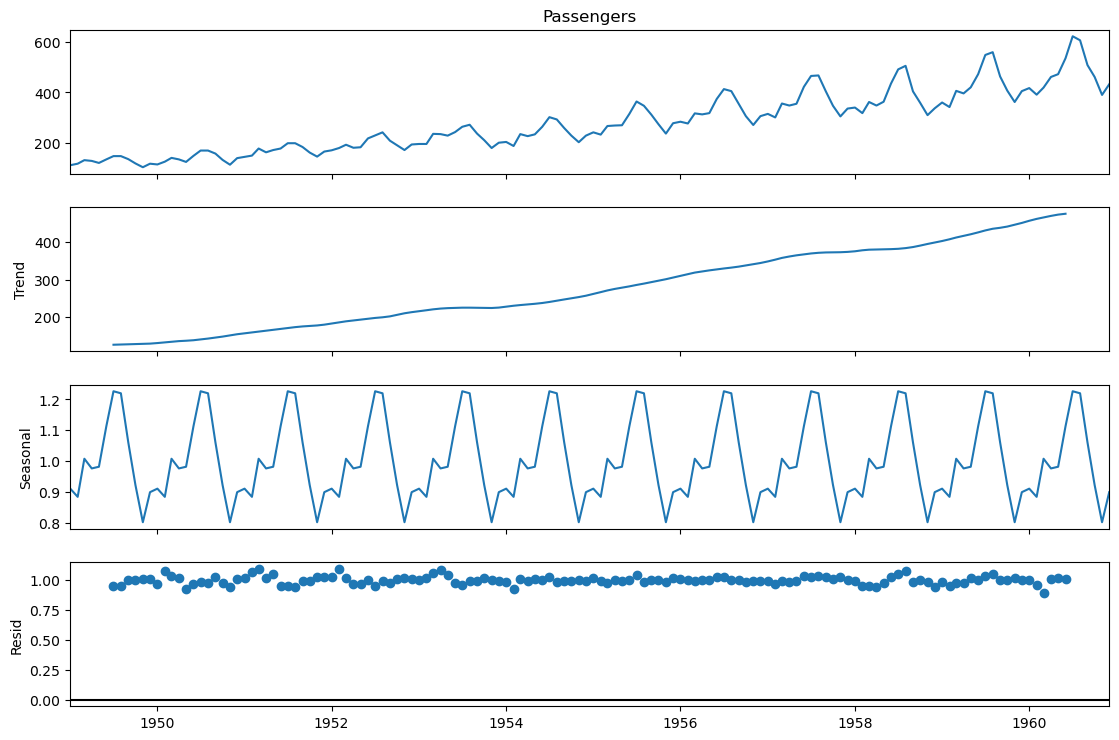

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decompose_result=seasonal_decompose(airline['Passengers'],model='multiplicative')
fig=decompose_result.plot()
fig.set_size_inches(12,8)
plt.show()

In [10]:
pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


In [11]:
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(airline['Passengers'].dropna().values)
print(f"ADF Statistic: {test_result[0]}")                     
print(f" p value is : {test_result[1]}")

ADF Statistic: 0.8153688792060482
 p value is : 0.991880243437641


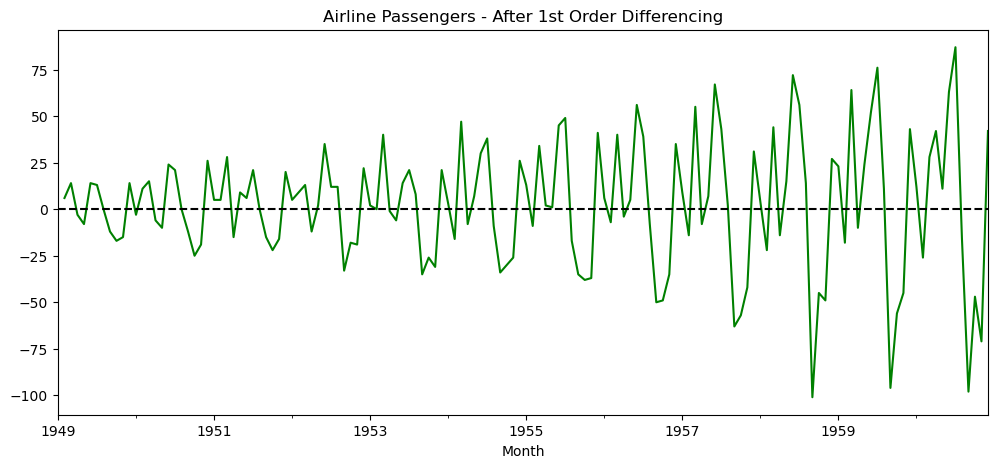

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
airline['Passengers_Diff'] = airline['Passengers'] - airline['Passengers'].shift(1)
airline['Passengers_Diff'].plot(figsize=(12, 5), color='green')
plt.title('Airline Passengers - After 1st Order Differencing')
plt.axhline(0, color='black', linestyle='--') 
plt.show()

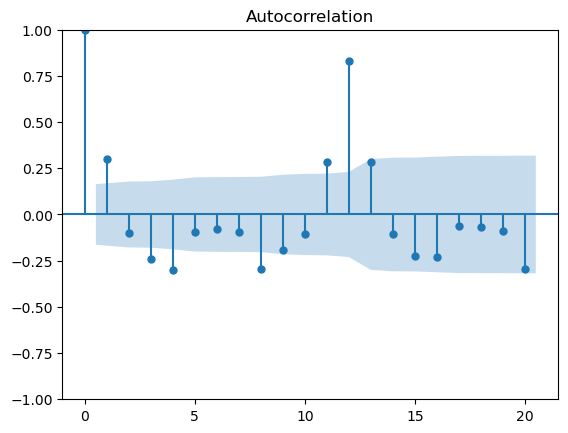

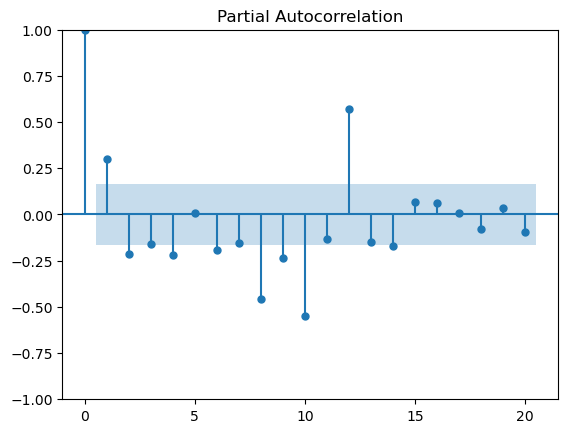

In [25]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(airline['Passengers_Diff'].dropna(),lags=20)
plt.show()
plot_pacf(airline['Passengers_Diff'].dropna(),lags=20)
plt.show()

In [30]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(airline['Passengers'],order=(2,1,2))
final_model=model.fit()
print(final_model.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Sun, 07 Jun 2026   AIC                           1353.347
Time:                        00:28:39   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.059      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.419      0.000      -0.989      -0.921
ma.L1         -1.8432      0.125    -14.798      0.0

In [34]:
pip install pmdarima

  Obtaining dependency information for pmdarima from https://files.pythonhosted.org/packages/f1/63/7550687289f41ab3b58223841e47a0454df923bf76304b6ca09d29b4f169/pmdarima-2.1.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for Cython!=0.29.18,!=0.29.31,>=0.29 from https://files.pythonhosted.org/packages/f0/a2/073335aea9343605c66144f9768217cf502be1cecb60ceadd3902e57d065/cython-3.2.5-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/722.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 kB ? eta -:--:--
    --------------------------------------- 10.2/722.6 k

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.


In [35]:
import pmdarima as pm
best_model=pm.auto_arima(airline['Passengers'],trace=True)
print(best_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.20 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

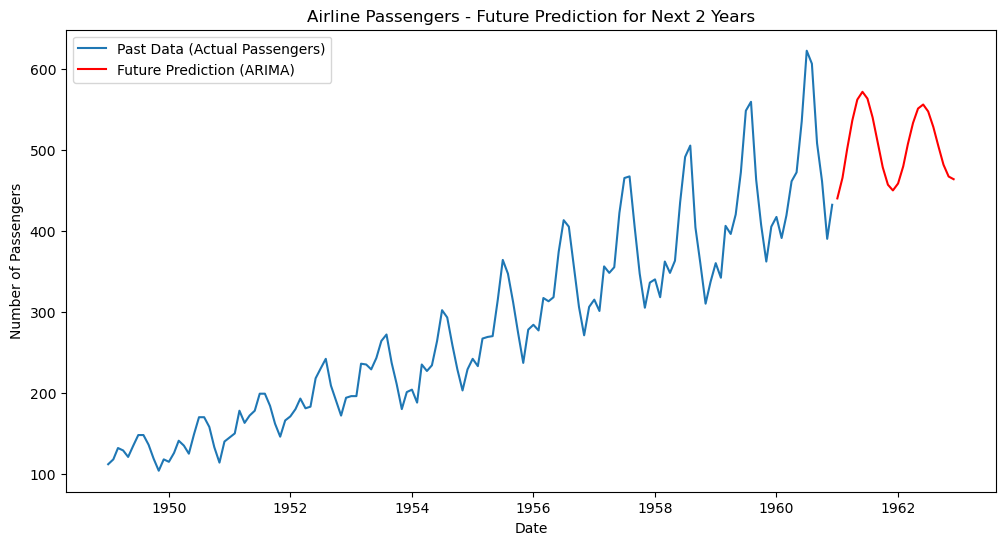

In [33]:
import matplotlib.pyplot as plt
future_prediction=final_model.forecast(steps=24)
plt.figure(figsize=(12, 6))
plt.plot(airline['Passengers'], label='Past Data (Actual Passengers)')
plt.plot(future_prediction, color='red', label='Future Prediction (ARIMA)')
plt.title('Airline Passengers - Future Prediction for Next 2 Years')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [40]:
import pmdarima as pm
model2 = pm.auto_arima(airline['Passengers'], start_p=1, start_q=1, max_p=3, max_q=3, m=12, seasonal=True, trace=True)
print(model2.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1022.299, Time=0.55 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.16 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.30 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.00 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.41 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.23 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.44 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.62 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.35 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.18 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.90 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [43]:
import statsmodels.api as sm
final_sarima = sm.tsa.statespace.SARIMAX(airline['Passengers'],
                                         order=(0, 1, 1),
                                         seasonal_order=(0, 1, 0, 12))
results_sarima = final_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -508.319
Date:                             Sun, 07 Jun 2026   AIC                           1020.639
Time:                                     01:27:35   BIC                           1026.389
Sample:                                 01-01-1949   HQIC                          1022.975
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3184      0.063     -5.038      0.000      -0.442      -0.195
sigma2       137.2653     1

## 🎯 Model Selection & Conclusion

In this project, the objective was to accurately forecast Airline Passengers using time series analysis. Instead of relying on a single algorithm, a rigorous mathematical evaluation was conducted to determine the most robust model. 

* **Basic ARIMA (2, 1, 2):** Initially tested, this model yielded statistically significant parameters. However, it completely failed to capture the dataset's inherent seasonality (the recurring summer peaks and winter dips), resulting in an unrealistic, flat forecast trend.
* **Auto-ARIMA (Grid Search):** To address the seasonality, an automated grid search was deployed. While it successfully lowered the AIC score, the algorithm acted "greedily." It overfitted the model by forcing unnecessary seasonal parameters (like AR Lag 12), causing those specific P-values to exceed the 0.05 threshold, rendering the model statistically invalid.
* **Final SARIMA (0, 1, 1) x (0, 1, 0, 12):** Based on the Auto-ARIMA blueprint, manual parameter pruning was executed. By dropping the insignificant seasonal autoregressive terms, the perfect mathematical balance was achieved. 

**Result:** The pruned SARIMA model dropped the AIC score massively to **1020.63** while maintaining perfect statistical significance (**P-values < 0.05**) across all parameters. This project highlights the critical necessity of human analytical intervention in automated machine learning processes to prevent overfitting and ensure mathematical validity.

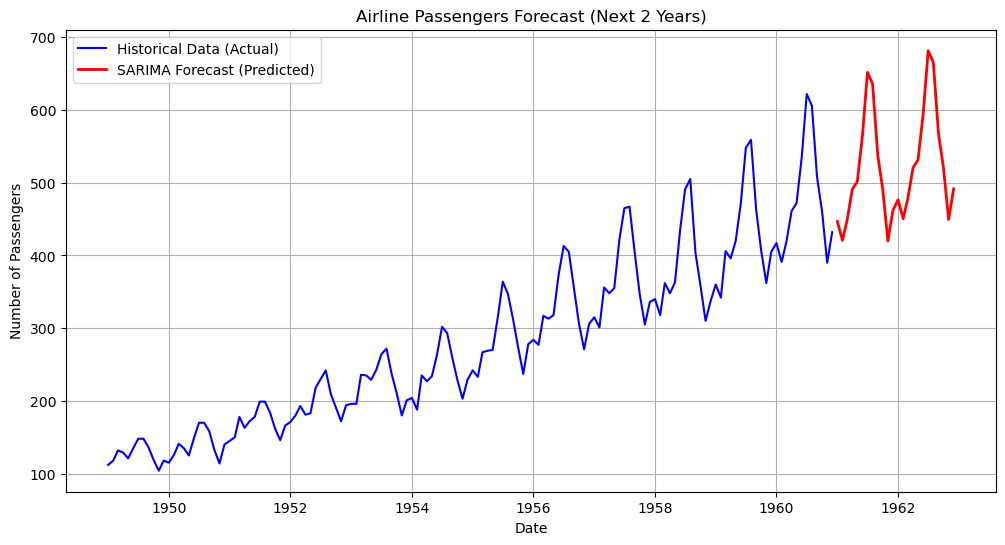

In [44]:
import matplotlib.pyplot as plt
future_forecast = results_sarima.forecast(steps=24)
plt.figure(figsize=(12, 6))
plt.plot(airline['Passengers'], label='Historical Data (Actual)', color='blue')
plt.plot(future_forecast, label='SARIMA Forecast (Predicted)', color='red', linewidth=2)
plt.title('Airline Passengers Forecast (Next 2 Years)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True) 
plt.show()

# Airline Passenger Forecasting: A SARIMA Approach

## Executive Summary
This project aims to forecast monthly airline passenger numbers using Time Series Analysis. Moving beyond simplistic trend models, this solution leverages **SARIMA (Seasonal Autoregressive Integrated Moving Average)** to account for complex seasonal patterns and yearly cyclic variations inherent in the aviation industry.

## Key Findings
- **Model Evolution:** The journey began with a baseline ARIMA model, which failed to capture seasonality. Subsequent automated grid searches (Auto-ARIMA) provided a solid blueprint but suffered from overfitting.
- **The Pruning Methodology:** By manually pruning insignificant seasonal autoregressive terms identified during statistical validation, we achieved a mathematically robust model.
- **Performance:** The final SARIMA (0, 1, 1) x (0, 1, 0, 12) model achieved an AIC of 1020.63, significantly outperforming the baseline ARIMA (1353). All model parameters passed the statistical significance tests (P-value < 0.05), ensuring reliable and actionable forecasting.

## Business Impact
The finalized model provides high-precision seasonal forecasts, allowing airlines to optimize resource allocation, manage fleet schedules, and predict passenger demand surges during peak summer and winter seasons.